# Membros do grupo

#### Bruno Calabria Cortez Navas - 13783947
#### Cauê Sordi Paulino - 14564520
#### Gustavo Curado Ribeiro - 14576732
#### Jose Manoel Vasconcelos Leopoldo - 12547451
#### Luís Filipe Silva Forti - 14592348
#### Miguel Rodrigues Fonseca - 14682196
#### Pedro Gabriel Ferreira Caliari 11800987

# Link para o dataset:
## http://millionsongdataset.com/pages/getting-dataset/#subset

In [6]:
from pathlib import Path
import h5py
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#Lê o dataset completo

musicas = []
raiz = Path("./MillionSongSubset")

#Lê todos os arquivos .h5
for arquivo in raiz.rglob("*.h5"):
    try:
        with h5py.File(arquivo, "r") as f:
            metadata = f["metadata"]["songs"][0]
            analysis = f["analysis"]["songs"][0]

            #Pega os dados nas colunas do arquivos
            musicas.append({
                "artist_name": metadata["artist_name"].decode("utf-8"),
                "title": metadata["title"].decode("utf-8"),

                "tempo": analysis["tempo"],
                "loudness": analysis["loudness"],
                "duration": analysis["duration"],
                "danceability": analysis["danceability"],
                "energy": analysis["energy"],
                "key": analysis["key"],
                "mode": analysis["mode"],
                "time_signature": analysis["time_signature"],

                "artist_hotttnesss": metadata["artist_hotttnesss"],
                "artist_familiarity": metadata["artist_familiarity"],
                "song_hotttnesss": metadata["song_hotttnesss"]
            })

    except Exception as e:
        print(f"Error reading {arquivo}: {e}")

#Salva as músicas lidas
df = pd.DataFrame(musicas)
print(f"Carregou {len(df)} músicas\n\n")

#Imprime a quantidade de dados vazios de cada coluna
missing = df.isna().sum()

print(f"{'Coluna':<35} {'Dados vazios':>12}")
print("-" * 50)

for col, count in missing.items():
    print(f"{col:<35} {count:>12}")

Carregou 10000 músicas


Coluna                              Dados vazios
--------------------------------------------------
artist_name                                    0
title                                          0
tempo                                          0
loudness                                       0
duration                                       0
danceability                                   0
energy                                         0
key                                            0
mode                                           0
time_signature                                 0
artist_hotttnesss                              0
artist_familiarity                             4
song_hotttnesss                             4352


In [8]:
#Separa os dados interessantes para a análise
colunas = [
    #artist_name, apesar de interessante, não foi incluido por não ser numérico
    "tempo",
    "loudness",
    "danceability",
    "energy",
    "key",
    "mode",
    "time_signature",
    "artist_hotttnesss",
    "artist_familiarity"
    #song_hotttnesss, apesar de interessante, não foi incluido pelo problema citado abaixo
]

#Todo dado que não tiver um valor é substituído pela mediana da coluna
#É importante, então, que a coluna não tenha muitos dados vazios
#Senão terão muitas substituições, afetando a análise
df[colunas] = df[colunas].fillna(df[colunas].median())

#Normaliza os dados
#Ou seja, agora todas as colunas terão valores ao redor de 0 e desvio padrão 1
#Isso é fundamental para que valores que tenham variação absoluta maior não dominem
#Ex: tempo pode variar de 80 a 160, enquanto danceability é apenas de 0 a 1
#Após a transformação, ambos ficarão entre -1 e 1
scaler = StandardScaler()
X = scaler.fit_transform(df[colunas])

In [9]:
#Inertia é uma medida de quão compactos ficaram os clusters
#Este código avalia as inertias de configuraçãos de 1 a 50 clusters
inertias = []
qtdClusters = range(1, 51)

for k in qtdClusters:
    model = KMeans(
        n_clusters=k,
        #42 == valor arbitrário para consistência
        random_state=42,
        #Quantas vezes deve repetir para escolher o melhor
        n_init=30
    )

    model.fit(X)
    inertias.append(model.inertia_)

In [10]:
#Algoritmo Kneedle, que avalia o ponto mais distante da reta entre o primeiro e último pontos
#A lógica por trás dele é que o "cotovelo" da curva é o ponto mais distante da reta
#Com o "cotovelo" sendo o ponto em que o uso de mais clusters gera rendimentos decrescentes

x = qtdClusters
y = np.array(inertias)

#Primeiro e último pontos
p1 = np.array([x[0], y[0]])
p2 = np.array([x[-1], y[-1]])

distancias = []

for i in range(len(x)):
    #Ponto atual
    p = np.array([x[i], y[i]])

    #           | (p2 - p1) × (p1 - p) |
    # d =       -------------------------
    #                  || p2 - p1 ||
    distancia = np.abs(
        np.cross(p2 - p1, p1 - p)
    ) / np.linalg.norm(p2 - p1)

    distancias.append(distancia)

#Pega o X (número de clusters) com a maior distância
idxCotovelo = np.argmax(distancias)
clustersCotovelo = x[idxCotovelo]
print(f"Cotovelo em NroClusters = {clustersCotovelo}")

Cotovelo em NroClusters = 11


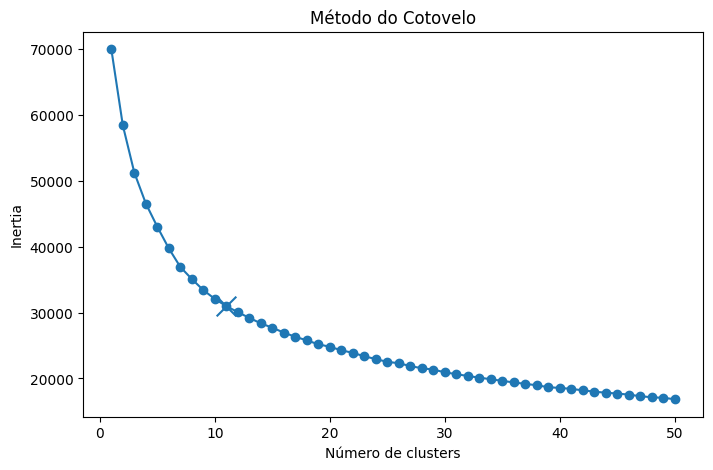

In [11]:
Ks = np.arange(1, len(inertias) + 1)

plt.figure(figsize=(8, 5))
plt.plot(Ks, inertias, marker='o')
plt.scatter(
    clustersCotovelo,
    inertias[clustersCotovelo - 1],
    s=200,
    marker='x'
)

plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo")
plt.show()

In [12]:
#Faz os clusters com o número obtido na etapa anterior
kmeans = KMeans(
    n_clusters=clustersCotovelo,
    random_state=42,
    n_init=100
)

#Adicioa a coluna "cluster" na tabela com os dados
df["cluster"] = kmeans.fit_predict(X)

In [13]:
#Imprime parte dos clusters, apenas para visualizar
for cluster in sorted(df["cluster"].unique()):
    print(f"\n===== Cluster {cluster} =====")

    sample = df[df["cluster"] == cluster].head(10)

    for _, song in sample.iterrows():
        print(
            f"{song['artist_name']} - {song['title']}"
        )


===== Cluster 0 =====
Wayne Watson - The Urgency (LP Version)
Andy Andy - La Culpa
Blue Rodeo - Floating
Richard Souther - High Tide
Faiz Ali Faiz - Sohna Nee Sohna Data
SUE THOMPSON - James (Hold The Ladder Steady)
Willie Bobo - Spanish Grease
Terry Callier - Do You Finally Need A Friend
Scarlet's Remains - Spin
John Hammond - I Can't Be Satisfied

===== Cluster 1 =====
lextrical - Synthetic Dream
Nadine Renee - Next Time
Bézu - Le tortillard
Howard Armstrong - My Four Reasons
Thomas Battenstein - Sympathy
Milan Band - Ciao Milan
Pascal Sangla - Une petite pause
Dakis - Perasmena Mesanihta
Deekline & Wizard - Sun Is Shining
Daniela Dessì - New Age

===== Cluster 2 =====
Adam Ant - Something Girls
Gob - Face the Ashes
Planet P Project - Pink World
Jimmy Wakely - Broken-Down Merry-Go-Round
Elena - Setanta matins
Roberto Torres - Sabor Guajiro
Loudon Wainwright III - Human Cannonball
R.L. Burnside - Glory Be
Casiotone For The Painfully Alone - Nashville Parthenon
Edith Lefel - An ti cha

In [14]:
#Função de recomendação
#Parâmetros: título da música e quantidade de recomendações
def Recomendar(title, n=10):
    #Procura pelas músicas com o nome passado
    matches = df[df["title"].str.lower() == title.lower()]

    #Se não achou nenhuma
    if len(matches) == 0:
        print("Song not found")
        return

    #Para cada música encontrada
    for _, musica in matches.iterrows():

        #Pega o cluster da música
        cluster = musica["cluster"]

        #Seleciona n músicas do mesmo cluster
        cluster_musicas = df[df["cluster"] == cluster]
        #Como sample é aleatório, cada execução terá resultados diferentes
        recomendacoes = cluster_musicas.sample(
            min(n, len(cluster_musicas))
        )

        #Imprime cabeçalho com o nome da música e do artista atual
        print("\n" + "=" * 60)
        print(f"Recomendações para: {musica['artist_name']} - {musica['title']}")
        print("=" * 60)

        #Imprime as recomendações
        for _, rec in recomendacoes.iterrows():
            #Evita recomendar a própria música
            if (rec["title"] == musica["title"] and rec["artist_name"] == musica["artist_name"]):
                continue

            print(f"{rec['artist_name']} - {rec['title']}")

In [15]:
print(df[['title', 'cluster']])

                                 title  cluster
0                     I Didn't Mean To        3
1                            Soul Deep        3
2                      Amor De Cabaret        7
3                      Something Girls        2
4                       Face the Ashes        2
...                                ...      ...
9995                    The Hanged Man        9
9996  The Wonderful World Of The Young        0
9997                   Sentimental Man        2
9998                 Zydeco In D-Minor        2
9999                    Shattered Life        3

[10000 rows x 2 columns]


In [16]:
Recomendar("I Didn't Mean To")


Recomendações para: Casual - I Didn't Mean To
Seventh Day Slumber - Shattered Life
Coven - Coven In Charing Cross
Milk Inc. - No Angel (radio/album)
NOFX - We March To The Beat Of Indifferent Drum
Leila Chicot - Tout bizwen (feat. Milca_ Synn'Tya_ Shaolin)
Brian Auger's Oblivion Express - Inner City Blues (Alternate Mix) (Bonus Track)
Dancecore Allstars - When The Sun Comes Out
Grant Geissman - Chaco (Album Version)
Terry Riley - Peace Dance
POLINA - Tora


In [17]:
for titulo in df[df['artist_name'] == 'U2']['title']:
    Recomendar(titulo)


Recomendações para: U2 - Kite Live from Sydney
Madonna - Celebration [Felguk Love Remix]
Mariah Carey - Mine Again
Three 6 Mafia - Let's Plan A Robbery
Phil Collins - That's What You Said  (LP Version)
Bruce Springsteen - Working On The Highway
David Cook - I Did it for You
Rancid - The Bravest Kids (Acoustic)
Curtis Mayfield - People Never Give Up
The Suicide Machines - Burning In The Aftermath
Brenda Lee - Against My Will (LP Version)

Recomendações para: U2 - New York
Hatebreed (int License) - Beholder of Justice (Album Version)
Shakira - Donde Estas Corazon
brokeNCYDE - Schitzo
Boyz II Men - Motownphilly
Hatebreed - As Diehard As They Come (Album Version)
Delbert McClinton - Lover In Demand
The Exies - Creeper Kamikaze
BT - Knowledge Of Self (Evol Intent Remix)
Jack Off Jill - Yellow Brick Road
NOFX - Stickin In My Eye

Recomendações para: U2 - Vertigo
3 Doors Down - It's Not Me
Del The Funky Homosapien - Corner Story
Foo Fighters - X-Static
Annie Lennox - Erased
Simply Red - Thri